# K-Means

In [1]:
import argparse
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from networkx import random_shell_graph
from sklearn.cluster import KMeans, OPTICS
from sklearn.decomposition import PCA
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr

from synthetic_graphs import generate_synthetic_graph, load_decoder

/home/snehpatel/research/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class LoadDataset(InMemoryDataset):
    """
    Loader for processed/SN_TT_data.pt produced by build_trace_graphs.py.
    Node features: [service_id, op_id, duration].
    Label: 0 for SN_Dataset, 1 for TT_Dataset.
    """

    def __init__(self, datapath="../processed/SN_data.pt") -> None:
        torch.serialization.add_safe_globals([Data, DataEdgeAttr, DataTensorAttr])
        super().__init__(".")
        data, slices = torch.load(datapath, weights_only=False)
        self.data, self.slices = data, slices

    def get(self, idx):
        return super().get(idx)


In [3]:
def extract_nodes(ds: InMemoryDataset):
    xs = []

    for i, graph in enumerate(ds):
        if graph.x is None:
            raise ValueError(f"Graph: {i} has no x")

        if graph.x.shape[1] != 3:
            raise ValueError(f"Expected 3 node feat got {graph.x.shape}")
        xs.append(graph.x.detach().cpu())

    return torch.cat(xs, dim=0)




In [4]:
def preprocess_sid_op_duration(X_real: torch.Tensor, X_syn: torch.Tensor):

    X_all = torch.cat([X_real, X_syn], dim=0)
    sid = X_all[:, 0].round().long()
    op = X_all[:, 1].round().long()
    dur = X_all[:, 2].float().unsqueeze(1)

    if (sid < 0).any() or (op < 0).any():
        raise ValueError("Found neg Ids in service_id or op_id")

    n_sid = int(sid.max().item()) + 1
    n_op = int(op.max().item()) + 1

    # one-hot encode categorical IDs
    sid_oh = torch.nn.functional.one_hot(sid, num_classes=n_sid).float()
    op_oh = torch.nn.functional.one_hot(op, num_classes=n_op).float()

    # standardize duration only (then we will standardize the whole vector too)
    dur_np = dur.numpy()
    dur_scaled = StandardScaler().fit_transform(dur_np)  # [N,1]

    # Combine
    X_feat = torch.cat(
        [sid_oh, op_oh, torch.from_numpy(dur_scaled).float()], dim=1
    ).numpy()

    origin = np.array([0] * len(X_real) + [1] * len(X_syn))  # 0=real, 1=synthetic
    return X_feat, origin

## TT Fixed Dataset

In [6]:
real = LoadDataset(datapath="./processed/TT_data.pt")
synthetic = LoadDataset(datapath="./processed/exact_replica/prop_order_TT_synthetic_sample_nodes.pt")

In [7]:
Xr = extract_nodes(real).float()
Xs = extract_nodes(synthetic).float()

print(Xr.shape, Xs.shape)


torch.Size([7912, 3]) torch.Size([7912, 3])


In [11]:
X_feat, origin = preprocess_sid_op_duration(Xr, Xs)

X_feat = StandardScaler().fit_transform(X_feat)

print(
    "Final feature matrix:",
    X_feat.shape,
    "(one-hot sid + one-hot op + scaled duration)",
)

k = 2
km = KMeans(n_clusters=k, n_init=20, random_state=42)
cluster_id = km.fit_predict(X_feat)

print("\n=== Cluster mixing (fraction synthetic per cluster) ===")
for c in range(k):
    idx = np.where(cluster_id == c)[0]
    frac_syn = origin[idx].mean() if len(idx) else float("nan")
    print(f"cluster {c:02d}: n={len(idx):6d}  frac_syn={frac_syn:.3f}")

nmi = normalized_mutual_info_score(origin, cluster_id)
print("\nNMI(origin vs cluster):", float(nmi), " (0=mixed, higher=separable)")


Final feature matrix: (15824, 30) (one-hot sid + one-hot op + scaled duration)

=== Cluster mixing (fraction synthetic per cluster) ===
cluster 00: n=  1969  frac_syn=0.495
cluster 01: n= 13855  frac_syn=0.501

NMI(origin vs cluster): 1.512493180519671e-05  (0=mixed, higher=separable)


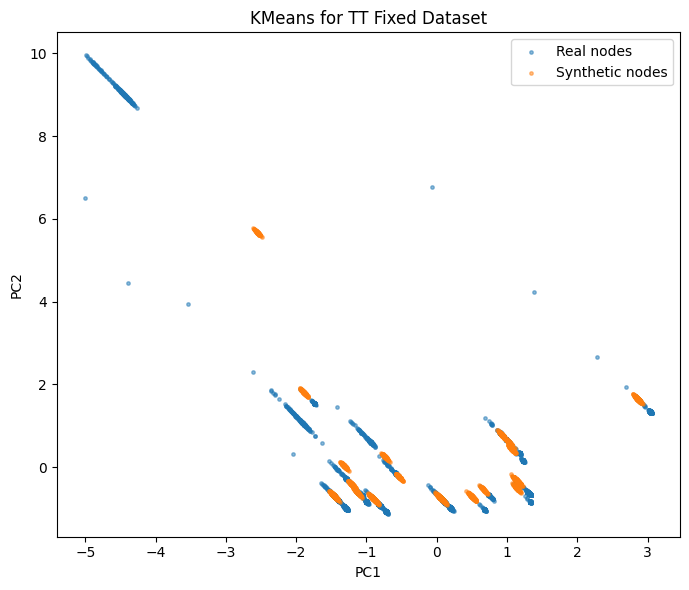

In [12]:
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X_feat)

plt.figure(figsize=(7, 6))
plt.scatter(Xp[origin == 0, 0], Xp[origin == 0, 1], s=6, alpha=0.5, label="Real nodes")
plt.scatter(
    Xp[origin == 1, 0], Xp[origin == 1, 1], s=6, alpha=0.5, label="Synthetic nodes"
)
plt.title("KMeans for TT Fixed Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_fixed_TT_PCA.png", dpi=300, bbox_inches="tight")

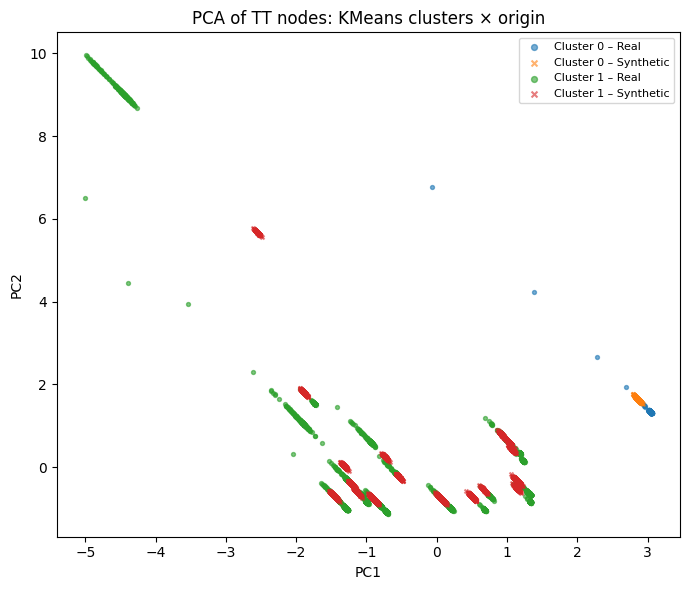

In [13]:
plt.figure(figsize=(7,6))

for c in range(k):
    for origin_label, marker, name in [
        (0, "o", "Real"),
        (1, "x", "Synthetic"),
    ]:
        idx = (cluster_id == c) & (origin == origin_label)
        if idx.sum() == 0:
            continue
        plt.scatter(
            Xp[idx, 0],
            Xp[idx, 1],
            s=8,
            alpha=0.6,
            marker=marker,
            label=f"Cluster {c} – {name}"
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TT nodes: KMeans clusters × origin")

plt.legend(markerscale=1.5, fontsize=8)
plt.tight_layout()
plt.show()


### Nearest-neighbor Similarity Plot 

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

X_real = X_feat[origin == 0]
X_syn = X_feat[origin == 1]

print(f"X_real: {X_real.shape}")
print(f"X_syn: {X_syn.shape}")

# Real -> Real (Exclude self)
nn_real = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_rr, idx_rr = nn_real.kneighbors(X_real)
dist_rr = dist_rr[:,1]

# Synthetic -> Real 
nn_real_1 = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_sr, idx_sr = nn_real_1.kneighbors(X_syn)
dist_sr = dist_sr[:, 0]

nn_syn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=-1    
).fit(X_syn)

dist_rs, idx_rs = nn_syn.kneighbors(X_real)
dist_rs = dist_rs[:, 0]



X_real: (7912, 30)
X_syn: (7912, 30)


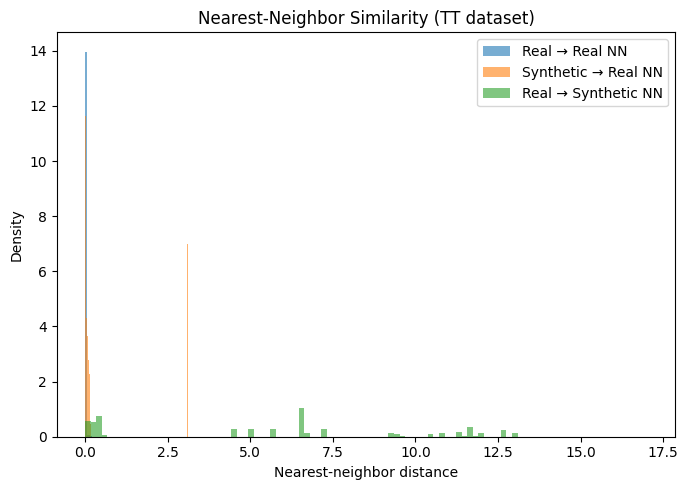

In [54]:
# ----------------------------
# Plot distributions
# ----------------------------
plt.figure(figsize=(7,5))

plt.hist(
    dist_rr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Real NN"
)

plt.hist(
    dist_sr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Synthetic → Real NN"
)

plt.hist(
    dist_rs,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Synthetic NN"
)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Density")
plt.title("Nearest-Neighbor Similarity (TT dataset)")
plt.legend()

plt.tight_layout()
plt.show()


In [55]:
def summarize(name, d):
    print(
        f"{name:25s} "
        f"mean={d.mean():.4f}  "
        f"p10={np.percentile(d,10):.4f}  "
        f"p50={np.percentile(d,50):.4f}  "
        f"p90={np.percentile(d,90):.4f}"
    )

print("\n=== NN Distance Summary ===")
summarize("Real → Real", dist_rr)
summarize("Synthetic → Real", dist_sr)
summarize("Real → Synthetic", dist_rs)


=== NN Distance Summary ===
Real → Real               mean=0.0059  p10=0.0000  p50=0.0001  p90=0.0019
Synthetic → Real          mean=0.7181  p10=0.0045  p50=0.0632  p90=3.1109
Real → Synthetic          mean=5.6842  p10=0.1866  p50=6.5073  p90=11.6400


### Real-vs-Fake RF Model

In [17]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [57]:
X_real[0], X_syn[0]

(array([ 8.861015  , -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
        -0.81042576, -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185, -0.96497107,
        -0.11285388, -0.09749658,  8.861015  , -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388, -0.6848924 ],
       dtype=float32),
 array([-0.11285388, -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
         1.2339194 , -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185,  1.0363004 ,
        -0.11285388, -0.09749658, -0.11285388, -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388,  0.16322179],
       dtype=float32))

In [58]:
# X_real, X_syn: numpy arrays (N, D)
X_real = np.asarray(X_real)
X_syn  = np.asarray(X_syn)
X_real.shape, X_syn.shape

((7912, 30), (7912, 30))

In [59]:
# 1) Build X and y
X = np.vstack([X_real, X_syn])
y = np.concatenate([
    np.zeros(len(X_real), dtype=np.int64),
    np.ones(len(X_syn),  dtype=np.int64),
])

# 2) Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3) Simple, conservative RF discriminator
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

# 4) Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"RF real-vs-synthetic accuracy: {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=["Real", "Synthetic"]))



RF real-vs-synthetic accuracy: 0.9884
Confusion matrix (rows=true, cols=pred):
[[2342   32]
 [  23 2351]]

Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2374
   Synthetic       0.99      0.99      0.99      2374

    accuracy                           0.99      4748
   macro avg       0.99      0.99      0.99      4748
weighted avg       0.99      0.99      0.99      4748



In [15]:
def extract_features(dataset):
    """Extract graph-level features from PyG dataset"""
    features = []
    for data in dataset:
        # Example feature extraction - customize based on what's meaningful
        graph_features = [
            data.num_nodes,                           # Number of nodes
            data.num_edges,                           # Number of edges
            data.x[:, 2].mean().item(),              # Mean duration
            data.x[:, 2].std().item(),               # Std duration
            data.x[:, 2].max().item(),               # Max duration
            data.x[:, 2].min().item(),               # Min duration
            data.num_edges / data.num_nodes if data.num_nodes > 0 else 0,  # Avg degree
        ]
        features.append(graph_features)
    return np.array(features)

In [21]:
real_TT = LoadDataset(datapath="./processed/TT_data.pt")
real_SN = LoadDataset(datapath="./processed/SN_data.pt")
synthetic_TT = LoadDataset(datapath="./processed/exact_replica/prop_order_TT_synthetic_sample_nodes.pt")
synthetic_SN = LoadDataset(datapath="./processed/exact_replica/prop_order_SN_synthetic_sample_nodes.pt")


X_train_TT = extract_features(synthetic_TT)
X_train_SN = extract_features(synthetic_SN)
X_test_TT = extract_features(real_TT)
X_test_SN = extract_features(real_SN)

X_train = np.vstack([X_train_TT, X_train_SN])
y_train = np.hstack([np.zeros(len(X_train_SN)), np.ones(len(X_train_TT))])

X_test = np.vstack([X_test_TT, X_test_SN])
y_test = np.hstack([np.zeros(len(X_test_TT)), np.ones(len(X_test_SN))])


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['TT', 'SN']))

# Feature importance
feature_names = ['num_nodes', 'num_edges', 'mean_duration', 'std_duration', 
                 'max_duration', 'min_duration', 'avg_degree']
importances = rf.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

/tmp/ipykernel_1489911/3979956907.py:10: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  data.x[:, 2].std().item(),               # Std duration


Accuracy: 0.7826

Classification Report:
              precision    recall  f1-score   support

          TT       0.78      0.78      0.78      1244
          SN       0.78      0.79      0.78      1244

    accuracy                           0.78      2488
   macro avg       0.78      0.78      0.78      2488
weighted avg       0.78      0.78      0.78      2488

mean_duration: 0.2516
max_duration: 0.2506
min_duration: 0.2034
std_duration: 0.1757
num_nodes: 0.0708
num_edges: 0.0469
avg_degree: 0.0009


In [ ]:
real = LoadDataset(datapath="./processed/TT_data.pt")
synthetic = LoadDataset(datapath="./processed/exact_replica/prop_order_TT_synthetic_sample_nodes.pt")

In [63]:
Xr = extract_nodes(real).float()
Xs = extract_nodes(synthetic).float()

print(Xr.shape, Xs.shape)


torch.Size([7912, 3]) torch.Size([7912, 3])


In [64]:
X_feat, origin = preprocess_sid_op_duration(Xr, Xs)

X_feat = StandardScaler().fit_transform(X_feat)

print(
    "Final feature matrix:",
    X_feat.shape,
    "(one-hot sid + one-hot op + scaled duration)",
)

k = 2
km = KMeans(n_clusters=k, n_init=20, random_state=42)
cluster_id = km.fit_predict(X_feat)

print("\n=== Cluster mixing (fraction synthetic per cluster) ===")
for c in range(k):
    idx = np.where(cluster_id == c)[0]
    frac_syn = origin[idx].mean() if len(idx) else float("nan")
    print(f"cluster {c:02d}: n={len(idx):6d}  frac_syn={frac_syn:.3f}")

nmi = normalized_mutual_info_score(origin, cluster_id)
print("\nNMI(origin vs cluster):", float(nmi), " (0=mixed, higher=separable)")


Final feature matrix: (15824, 30) (one-hot sid + one-hot op + scaled duration)

=== Cluster mixing (fraction synthetic per cluster) ===
cluster 00: n= 14829  frac_syn=0.534
cluster 01: n=   995  frac_syn=0.000

NMI(origin vs cluster): 0.09848577306851597  (0=mixed, higher=separable)


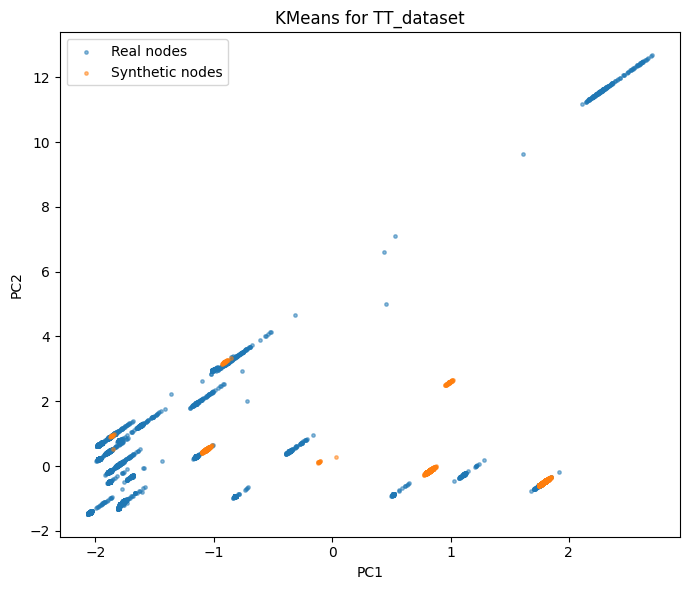

In [65]:
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X_feat)

plt.figure(figsize=(7, 6))
plt.scatter(Xp[origin == 0, 0], Xp[origin == 0, 1], s=6, alpha=0.5, label="Real nodes")
plt.scatter(
    Xp[origin == 1, 0], Xp[origin == 1, 1], s=6, alpha=0.5, label="Synthetic nodes"
)
plt.title("KMeans for TT_dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_fixed_TT_PCA.png", dpi=300, bbox_inches="tight")

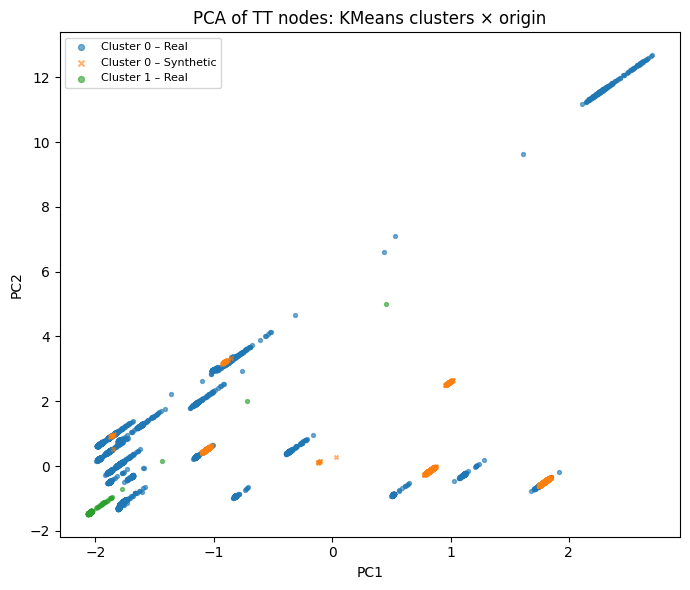

In [66]:
plt.figure(figsize=(7,6))

for c in range(k):
    for origin_label, marker, name in [
        (0, "o", "Real"),
        (1, "x", "Synthetic"),
    ]:
        idx = (cluster_id == c) & (origin == origin_label)
        if idx.sum() == 0:
            continue
        plt.scatter(
            Xp[idx, 0],
            Xp[idx, 1],
            s=8,
            alpha=0.6,
            marker=marker,
            label=f"Cluster {c} – {name}"
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TT nodes: KMeans clusters × origin")

plt.legend(markerscale=1.5, fontsize=8)
plt.tight_layout()
plt.show()


### Nearest-neighbor Similarity Plot 

In [67]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

X_real = X_feat[origin == 0]
X_syn = X_feat[origin == 1]

print(f"X_real: {X_real.shape}")
print(f"X_syn: {X_syn.shape}")

# Real -> Real (Exclude self)
nn_real = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_rr, idx_rr = nn_real.kneighbors(X_real)
dist_rr = dist_rr[:,1]

# Synthetic -> Real 
nn_real_1 = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_sr, idx_sr = nn_real_1.kneighbors(X_syn)
dist_sr = dist_sr[:, 0]

nn_syn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=-1    
).fit(X_syn)

dist_rs, idx_rs = nn_syn.kneighbors(X_real)
dist_rs = dist_rs[:, 0]



X_real: (7912, 30)
X_syn: (7912, 30)


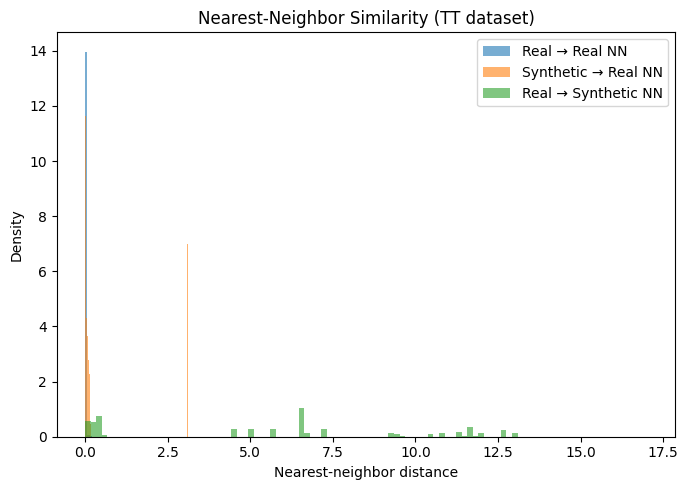

In [68]:
# ----------------------------
# Plot distributions
# ----------------------------
plt.figure(figsize=(7,5))

plt.hist(
    dist_rr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Real NN"
)

plt.hist(
    dist_sr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Synthetic → Real NN"
)

plt.hist(
    dist_rs,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Synthetic NN"
)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Density")
plt.title("Nearest-Neighbor Similarity (TT dataset)")
plt.legend()

plt.tight_layout()
plt.show()


In [69]:
def summarize(name, d):
    print(
        f"{name:25s} "
        f"mean={d.mean():.4f}  "
        f"p10={np.percentile(d,10):.4f}  "
        f"p50={np.percentile(d,50):.4f}  "
        f"p90={np.percentile(d,90):.4f}"
    )

print("\n=== NN Distance Summary ===")
summarize("Real → Real", dist_rr)
summarize("Synthetic → Real", dist_sr)
summarize("Real → Synthetic", dist_rs)


=== NN Distance Summary ===
Real → Real               mean=0.0059  p10=0.0000  p50=0.0001  p90=0.0019
Synthetic → Real          mean=0.7181  p10=0.0045  p50=0.0632  p90=3.1109
Real → Synthetic          mean=5.6842  p10=0.1866  p50=6.5073  p90=11.6400


### Real-vs-Fake RF Model

In [70]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [71]:
X_real[0], X_syn[0]

(array([ 8.861015  , -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
        -0.81042576, -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185, -0.96497107,
        -0.11285388, -0.09749658,  8.861015  , -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388, -0.6848924 ],
       dtype=float32),
 array([-0.11285388, -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
         1.2339194 , -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185,  1.0363004 ,
        -0.11285388, -0.09749658, -0.11285388, -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388,  0.16322179],
       dtype=float32))

In [72]:
# X_real, X_syn: numpy arrays (N, D)
X_real = np.asarray(X_real)
X_syn  = np.asarray(X_syn)
X_real.shape, X_syn.shape

((7912, 30), (7912, 30))

In [73]:
# 1) Build X and y
X = np.vstack([X_real, X_syn])
y = np.concatenate([
    np.zeros(len(X_real), dtype=np.int64),
    np.ones(len(X_syn),  dtype=np.int64),
])

# 2) Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3) Simple, conservative RF discriminator
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

# 4) Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"RF real-vs-synthetic accuracy: {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=["Real", "Synthetic"]))



RF real-vs-synthetic accuracy: 0.9884
Confusion matrix (rows=true, cols=pred):
[[2342   32]
 [  23 2351]]

Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2374
   Synthetic       0.99      0.99      0.99      2374

    accuracy                           0.99      4748
   macro avg       0.99      0.99      0.99      4748
weighted avg       0.99      0.99      0.99      4748



In [74]:
def extract_features(dataset):
    """Extract graph-level features from PyG dataset"""
    features = []
    for data in dataset:
        # Example feature extraction - customize based on what's meaningful
        graph_features = [
            data.num_nodes,                           # Number of nodes
            data.num_edges,                           # Number of edges
            data.x[:, 2].mean().item(),              # Mean duration
            data.x[:, 2].std().item(),               # Std duration
            data.x[:, 2].max().item(),               # Max duration
            data.x[:, 2].min().item(),               # Min duration
            data.num_edges / data.num_nodes if data.num_nodes > 0 else 0,  # Avg degree
        ]
        features.append(graph_features)
    return np.array(features)

In [75]:
real_TT = LoadDataset(datapath="./processed/TT_data.pt")
real_SN = LoadDataset(datapath="./processed/SN_data.pt")
synthetic_TT = LoadDataset(datapath="./processed/exact_replica/prop_order_TT_synthetic.pt")
synthetic_SN = LoadDataset(datapath="./processed/exact_replica/prop_order_SN_synthetic.pt")


X_train_TT = extract_features(synthetic_TT)
X_train_SN = extract_features(synthetic_SN)
X_test_TT = extract_features(real_TT)
X_test_SN = extract_features(real_SN)

X_train = np.vstack([X_train_TT, X_train_SN])
y_train = np.hstack([np.zeros(len(X_train_SN)), np.ones(len(X_train_TT))])

X_test = np.vstack([X_test_TT, X_test_SN])
y_test = np.hstack([np.zeros(len(X_test_TT)), np.ones(len(X_test_SN))])


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['TT', 'SN']))

# Feature importance
feature_names = ['num_nodes', 'num_edges', 'mean_duration', 'std_duration', 
                 'max_duration', 'min_duration', 'avg_degree']
importances = rf.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

/tmp/ipykernel_400956/3979956907.py:10: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  data.x[:, 2].std().item(),               # Std duration


Accuracy: 0.7725

Classification Report:
              precision    recall  f1-score   support

          TT       0.78      0.76      0.77      1244
          SN       0.77      0.79      0.78      1244

    accuracy                           0.77      2488
   macro avg       0.77      0.77      0.77      2488
weighted avg       0.77      0.77      0.77      2488

mean_duration: 0.2525
max_duration: 0.2501
min_duration: 0.2039
std_duration: 0.1743
num_nodes: 0.0685
num_edges: 0.0480
avg_degree: 0.0026


## 10% Split

In [49]:
# Extract features from all datasets
real_TT_features = extract_features(real_TT)
real_SN_features = extract_features(real_SN)
synthetic_TT_features = extract_features(synthetic_TT)
synthetic_SN_features = extract_features(synthetic_SN)

# Split real data: 10% train, 90% test
real_TT_train, real_TT_test = train_test_split(real_TT_features, test_size=0.98, random_state=42)
real_SN_train, real_SN_test = train_test_split(real_SN_features, test_size=0.98, random_state=42)


# Combine training data: all synthetic + 10% real
X_train = np.vstack([synthetic_TT_features, synthetic_SN_features, real_TT_train, real_SN_train])
y_train = np.hstack([
    np.zeros(len(synthetic_SN_features)),  # Synthetic TT
    np.ones(len(synthetic_TT_features)),   # Synthetic SN
    np.zeros(len(real_SN_train)),          # Real TT (10%)
    np.ones(len(real_TT_train))            # Real SN (10%)
])

# Test data: 90% real
X_test = np.vstack([real_TT_test, real_SN_test])
y_test = np.hstack([
    np.zeros(len(real_SN_test)),  # Real TT (90%)
    np.ones(len(real_TT_test))    # Real SN (90%)
])

print(f"Training set size: {len(X_train)} (Synthetic: {len(synthetic_TT_features) + len(synthetic_SN_features)}, Real: {len(real_TT_train) + len(real_SN_train)})")
print(f"Test set size: {len(X_test)}")

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['TT', 'SN']))

# Feature importance
feature_names = ['num_nodes', 'num_edges', 'mean_duration', 'std_duration', 
                 'max_duration', 'min_duration', 'avg_degree']
importances = rf.feature_importances_
print("\nFeature Importances:")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

/tmp/ipykernel_3493385/3979956907.py:10: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  data.x[:, 2].std().item(),               # Std duration


Training set size: 2536 (Synthetic: 2488, Real: 48)
Test set size: 2440

Accuracy: 0.9939

Classification Report:
              precision    recall  f1-score   support

          TT       0.99      1.00      0.99      1220
          SN       1.00      0.99      0.99      1220

    accuracy                           0.99      2440
   macro avg       0.99      0.99      0.99      2440
weighted avg       0.99      0.99      0.99      2440


Feature Importances:
mean_duration: 0.2763
max_duration: 0.2217
min_duration: 0.2003
std_duration: 0.1867
num_nodes: 0.0685
num_edges: 0.0444
avg_degree: 0.0020


## TT Variable Dataset

In [33]:
real = LoadDataset(datapath="./processed/TT_data.pt")
synthetic = LoadDataset(datapath="./processed/not_exact_replica/TT_synthetic.pt")

In [34]:
Xr = extract_nodes(real).float()
Xs = extract_nodes(synthetic).float()

print(Xr.shape, Xs.shape)


torch.Size([7912, 3]) torch.Size([14982, 3])


In [ ]:
X_feat, origin = preprocess_sid_op_duration(Xr, Xs)

X_feat = StandardScaler().fit_transform(X_feat)

print(
    "Final feature matrix:",
    X_feat.shape,
    "(one-hot sid + one-hot op + scaled duration)",
)

k = 2
km = KMeans(n_clusters=k, n_init=20, random_state=42)
cluster_id = km.fit_predict(X_feat)

print("\n=== Cluster mixing (fraction synthetic per cluster) ===")
for c in range(k):
    idx = np.where(cluster_id == c)[0]
    frac_syn = origin[idx].mean() if len(idx) else float("nan")
    print(f"cluster {c:02d}: n={len(idx):6d}  frac_syn={frac_syn:.3f}")

nmi = normalized_mutual_info_score(origin, cluster_id)
print("\nNMI(origin vs cluster):", float(nmi), " (0=mixed, higher=separable)")


Final feature matrix: (22894, 30) (one-hot sid + one-hot op + scaled duration)

=== Cluster mixing (fraction synthetic per cluster) ===
cluster 00: n=   995  frac_syn=0.000
cluster 01: n= 21899  frac_syn=0.684

NMI(origin vs cluster): 0.1167598375854589  (0=mixed, higher=separable)


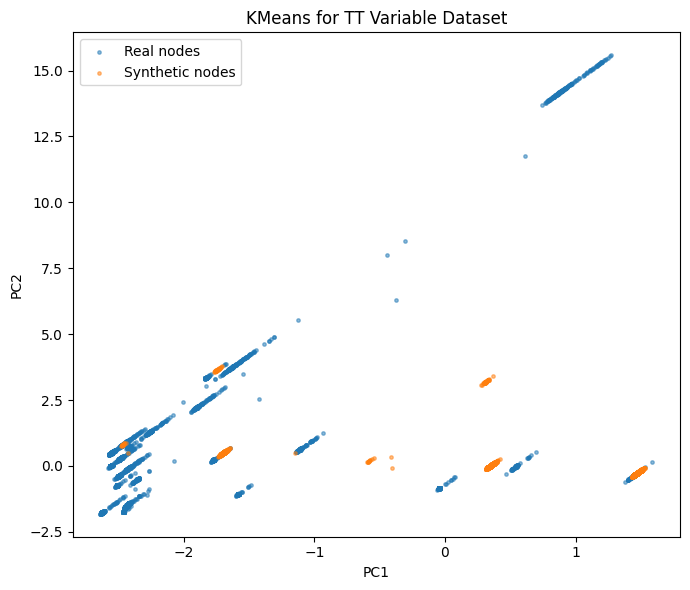

In [37]:
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X_feat)

plt.figure(figsize=(7, 6))
plt.scatter(Xp[origin == 0, 0], Xp[origin == 0, 1], s=6, alpha=0.5, label="Real nodes")
plt.scatter(
    Xp[origin == 1, 0], Xp[origin == 1, 1], s=6, alpha=0.5, label="Synthetic nodes"
)
plt.title("KMeans for TT Variable Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_variable_TT_PCA.png", dpi=300, bbox_inches="tight")

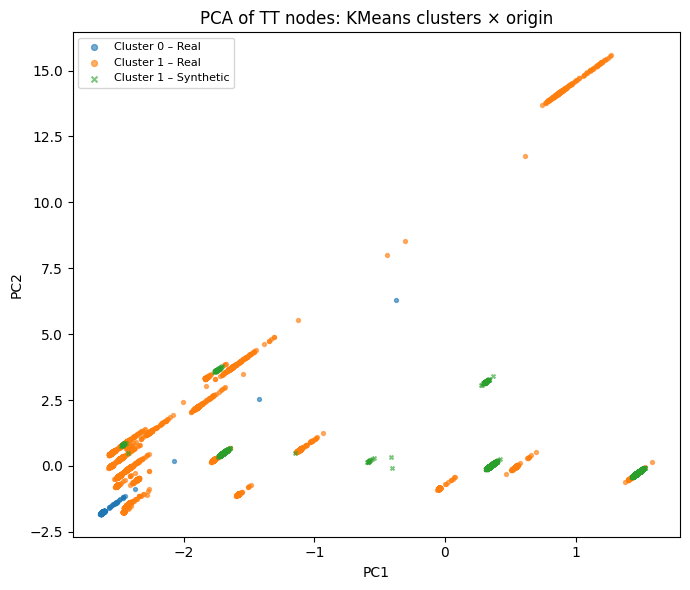

In [29]:
plt.figure(figsize=(7,6))

for c in range(k):
    for origin_label, marker, name in [
        (0, "o", "Real"),
        (1, "x", "Synthetic"),
    ]:
        idx = (cluster_id == c) & (origin == origin_label)
        if idx.sum() == 0:
            continue
        plt.scatter(
            Xp[idx, 0],
            Xp[idx, 1],
            s=8,
            alpha=0.6,
            marker=marker,
            label=f"Cluster {c} – {name}"
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TT nodes: KMeans clusters × origin")

plt.legend(markerscale=1.5, fontsize=8)
plt.tight_layout()
plt.show()


### Nearest-neighbor Similarity Plot 

In [31]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

X_real = X_feat[origin == 0]
X_syn = X_feat[origin == 1]

print(f"X_real: {X_real.shape}")
print(f"X_syn: {X_syn.shape}")

# Real -> Real (Exclude self)
nn_real = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_rr, idx_rr = nn_real.kneighbors(X_real)
dist_rr = dist_rr[:,1]

# Synthetic -> Real 
nn_real_1 = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_sr, idx_sr = nn_real_1.kneighbors(X_syn)
dist_sr = dist_sr[:, 0]

nn_syn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=-1    
).fit(X_syn)

dist_rs, idx_rs = nn_syn.kneighbors(X_real)
dist_rs = dist_rs[:, 0]



X_real: (7912, 30)
X_syn: (14982, 30)


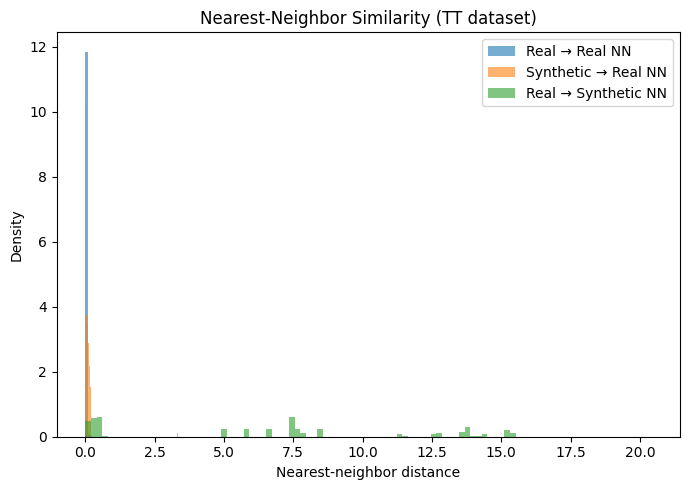

In [32]:
# ----------------------------
# Plot distributions
# ----------------------------
plt.figure(figsize=(7,5))

plt.hist(
    dist_rr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Real NN"
)

plt.hist(
    dist_sr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Synthetic → Real NN"
)

plt.hist(
    dist_rs,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Synthetic NN"
)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Density")
plt.title("Nearest-Neighbor Similarity (TT dataset)")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
def summarize(name, d):
    print(
        f"{name:25s} "
        f"mean={d.mean():.4f}  "
        f"p10={np.percentile(d,10):.4f}  "
        f"p50={np.percentile(d,50):.4f}  "
        f"p90={np.percentile(d,90):.4f}"
    )

print("\n=== NN Distance Summary ===")
summarize("Real → Real", dist_rr)
summarize("Synthetic → Real", dist_sr)
summarize("Real → Synthetic", dist_rs)


=== NN Distance Summary ===
Real → Real               mean=0.0059  p10=0.0000  p50=0.0001  p90=0.0019
Synthetic → Real          mean=0.7181  p10=0.0045  p50=0.0632  p90=3.1109
Real → Synthetic          mean=5.6842  p10=0.1866  p50=6.5073  p90=11.6400


### Real-vs-Fake RF Model

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
X_real[0], X_syn[0]

(array([ 8.861015  , -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
        -0.81042576, -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185, -0.96497107,
        -0.11285388, -0.09749658,  8.861015  , -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388, -0.6848924 ],
       dtype=float32),
 array([-0.11285388, -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
         1.2339194 , -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185,  1.0363004 ,
        -0.11285388, -0.09749658, -0.11285388, -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388,  0.16322179],
       dtype=float32))

In [ ]:
# X_real, X_syn: numpy arrays (N, D)
X_real = np.asarray(X_real)
X_syn  = np.asarray(X_syn)
X_real.shape, X_syn.shape

((7912, 30), (7912, 30))

In [ ]:
# 1) Build X and y
X = np.vstack([X_real, X_syn])
y = np.concatenate([
    np.zeros(len(X_real), dtype=np.int64),
    np.ones(len(X_syn),  dtype=np.int64),
])

# 2) Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3) Simple, conservative RF discriminator
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

# 4) Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"RF real-vs-synthetic accuracy: {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=["Real", "Synthetic"]))



RF real-vs-synthetic accuracy: 0.9884
Confusion matrix (rows=true, cols=pred):
[[2342   32]
 [  23 2351]]

Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2374
   Synthetic       0.99      0.99      0.99      2374

    accuracy                           0.99      4748
   macro avg       0.99      0.99      0.99      4748
weighted avg       0.99      0.99      0.99      4748



In [ ]:
def extract_features(dataset):
    """Extract graph-level features from PyG dataset"""
    features = []
    for data in dataset:
        # Example feature extraction - customize based on what's meaningful
        graph_features = [
            data.num_nodes,                           # Number of nodes
            data.num_edges,                           # Number of edges
            data.x[:, 2].mean().item(),              # Mean duration
            data.x[:, 2].std().item(),               # Std duration
            data.x[:, 2].max().item(),               # Max duration
            data.x[:, 2].min().item(),               # Min duration
            data.num_edges / data.num_nodes if data.num_nodes > 0 else 0,  # Avg degree
        ]
        features.append(graph_features)
    return np.array(features)

In [ ]:
real_TT = LoadDataset(datapath="./processed/TT_data.pt")
real_SN = LoadDataset(datapath="./processed/SN_data.pt")
synthetic_TT = LoadDataset(datapath="./processed/exact_replica/prop_order_TT_synthetic.pt")
synthetic_SN = LoadDataset(datapath="./processed/exact_replica/prop_order_SN_synthetic.pt")


X_train_TT = extract_features(synthetic_TT)
X_train_SN = extract_features(synthetic_SN)
X_test_TT = extract_features(real_TT)
X_test_SN = extract_features(real_SN)

X_train = np.vstack([X_train_TT, X_train_SN])
y_train = np.hstack([np.zeros(len(X_train_SN)), np.ones(len(X_train_TT))])

X_test = np.vstack([X_test_TT, X_test_SN])
y_test = np.hstack([np.zeros(len(X_test_TT)), np.ones(len(X_test_SN))])


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['TT', 'SN']))

# Feature importance
feature_names = ['num_nodes', 'num_edges', 'mean_duration', 'std_duration', 
                 'max_duration', 'min_duration', 'avg_degree']
importances = rf.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

/tmp/ipykernel_400956/3979956907.py:10: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  data.x[:, 2].std().item(),               # Std duration


Accuracy: 0.7725

Classification Report:
              precision    recall  f1-score   support

          TT       0.78      0.76      0.77      1244
          SN       0.77      0.79      0.78      1244

    accuracy                           0.77      2488
   macro avg       0.77      0.77      0.77      2488
weighted avg       0.77      0.77      0.77      2488

mean_duration: 0.2525
max_duration: 0.2501
min_duration: 0.2039
std_duration: 0.1743
num_nodes: 0.0685
num_edges: 0.0480
avg_degree: 0.0026


In [ ]:
real = LoadDataset(datapath="./processed/TT_data.pt")
synthetic = LoadDataset(datapath="./processed/exact_replica/prop_order_TT_synthetic.pt")

In [ ]:
Xr = extract_nodes(real).float()
Xs = extract_nodes(synthetic).float()

print(Xr.shape, Xs.shape)


torch.Size([7912, 3]) torch.Size([7912, 3])


In [ ]:
X_feat, origin = preprocess_sid_op_duration(Xr, Xs)

X_feat = StandardScaler().fit_transform(X_feat)

print(
    "Final feature matrix:",
    X_feat.shape,
    "(one-hot sid + one-hot op + scaled duration)",
)

k = 2
km = KMeans(n_clusters=k, n_init=20, random_state=42)
cluster_id = km.fit_predict(X_feat)

print("\n=== Cluster mixing (fraction synthetic per cluster) ===")
for c in range(k):
    idx = np.where(cluster_id == c)[0]
    frac_syn = origin[idx].mean() if len(idx) else float("nan")
    print(f"cluster {c:02d}: n={len(idx):6d}  frac_syn={frac_syn:.3f}")

nmi = normalized_mutual_info_score(origin, cluster_id)
print("\nNMI(origin vs cluster):", float(nmi), " (0=mixed, higher=separable)")


Final feature matrix: (15824, 30) (one-hot sid + one-hot op + scaled duration)

=== Cluster mixing (fraction synthetic per cluster) ===
cluster 00: n= 14829  frac_syn=0.534
cluster 01: n=   995  frac_syn=0.000

NMI(origin vs cluster): 0.09848577306851597  (0=mixed, higher=separable)


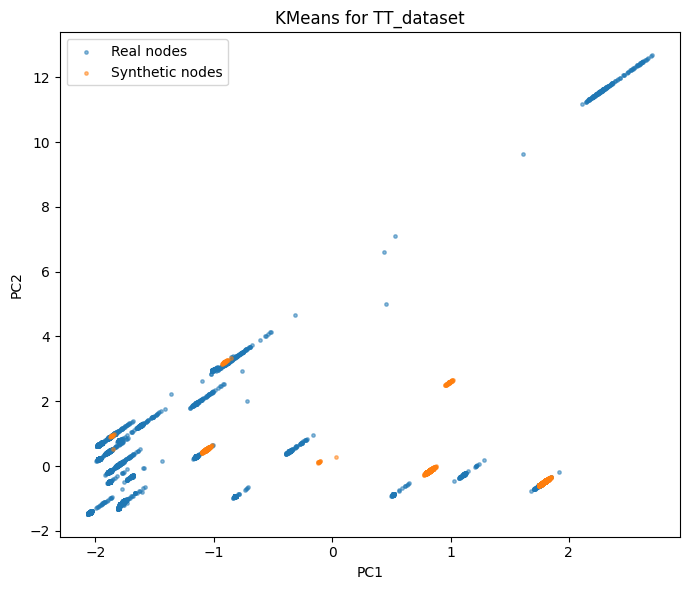

In [ ]:
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X_feat)

plt.figure(figsize=(7, 6))
plt.scatter(Xp[origin == 0, 0], Xp[origin == 0, 1], s=6, alpha=0.5, label="Real nodes")
plt.scatter(
    Xp[origin == 1, 0], Xp[origin == 1, 1], s=6, alpha=0.5, label="Synthetic nodes"
)
plt.title("KMeans for TT_dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_fixed_TT_PCA.png", dpi=300, bbox_inches="tight")

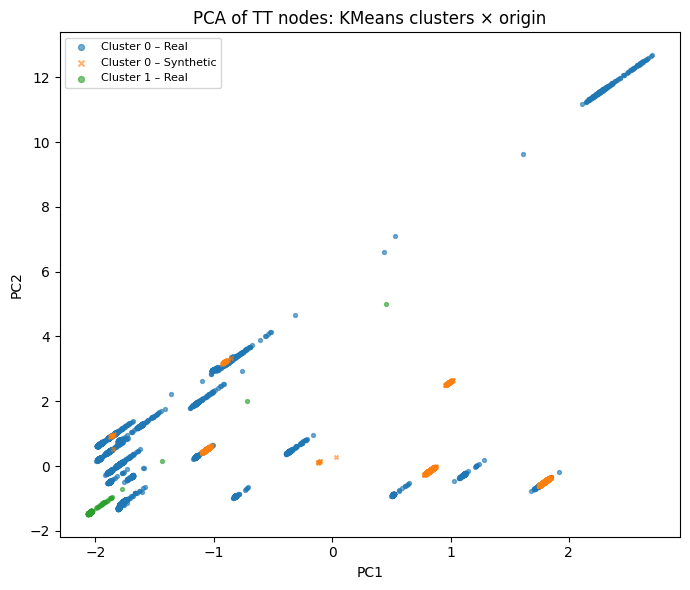

In [ ]:
plt.figure(figsize=(7,6))

for c in range(k):
    for origin_label, marker, name in [
        (0, "o", "Real"),
        (1, "x", "Synthetic"),
    ]:
        idx = (cluster_id == c) & (origin == origin_label)
        if idx.sum() == 0:
            continue
        plt.scatter(
            Xp[idx, 0],
            Xp[idx, 1],
            s=8,
            alpha=0.6,
            marker=marker,
            label=f"Cluster {c} – {name}"
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TT nodes: KMeans clusters × origin")

plt.legend(markerscale=1.5, fontsize=8)
plt.tight_layout()
plt.show()


### Nearest-neighbor Similarity Plot 

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

X_real = X_feat[origin == 0]
X_syn = X_feat[origin == 1]

print(f"X_real: {X_real.shape}")
print(f"X_syn: {X_syn.shape}")

# Real -> Real (Exclude self)
nn_real = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_rr, idx_rr = nn_real.kneighbors(X_real)
dist_rr = dist_rr[:,1]

# Synthetic -> Real 
nn_real_1 = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_sr, idx_sr = nn_real_1.kneighbors(X_syn)
dist_sr = dist_sr[:, 0]

nn_syn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=-1    
).fit(X_syn)

dist_rs, idx_rs = nn_syn.kneighbors(X_real)
dist_rs = dist_rs[:, 0]



X_real: (7912, 30)
X_syn: (7912, 30)


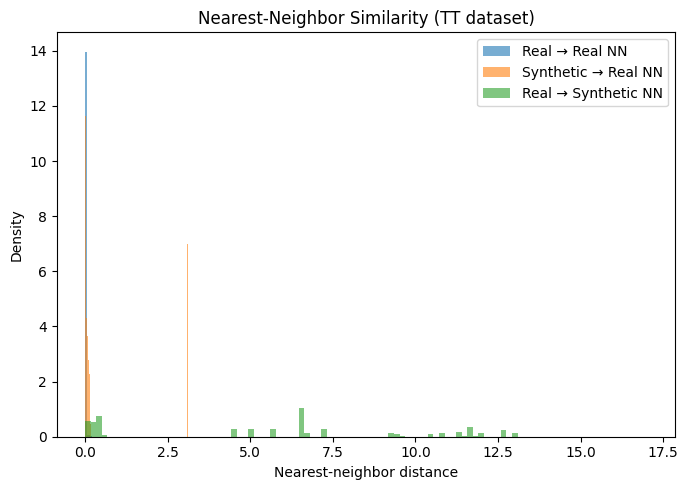

In [ ]:
# ----------------------------
# Plot distributions
# ----------------------------
plt.figure(figsize=(7,5))

plt.hist(
    dist_rr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Real NN"
)

plt.hist(
    dist_sr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Synthetic → Real NN"
)

plt.hist(
    dist_rs,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Synthetic NN"
)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Density")
plt.title("Nearest-Neighbor Similarity (TT dataset)")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
def summarize(name, d):
    print(
        f"{name:25s} "
        f"mean={d.mean():.4f}  "
        f"p10={np.percentile(d,10):.4f}  "
        f"p50={np.percentile(d,50):.4f}  "
        f"p90={np.percentile(d,90):.4f}"
    )

print("\n=== NN Distance Summary ===")
summarize("Real → Real", dist_rr)
summarize("Synthetic → Real", dist_sr)
summarize("Real → Synthetic", dist_rs)


=== NN Distance Summary ===
Real → Real               mean=0.0059  p10=0.0000  p50=0.0001  p90=0.0019
Synthetic → Real          mean=0.7181  p10=0.0045  p50=0.0632  p90=3.1109
Real → Synthetic          mean=5.6842  p10=0.1866  p50=6.5073  p90=11.6400


### Real-vs-Fake RF Model

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
X_real[0], X_syn[0]

(array([ 8.861015  , -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
        -0.81042576, -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185, -0.96497107,
        -0.11285388, -0.09749658,  8.861015  , -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388, -0.6848924 ],
       dtype=float32),
 array([-0.11285388, -0.1751515 , -0.23014733, -0.14995475, -0.11285388,
         1.2339194 , -0.19800673, -0.2590333 , -0.4485017 , -0.18940239,
        -0.23029952, -0.33573893, -0.14995475, -0.54424185,  1.0363004 ,
        -0.11285388, -0.09749658, -0.11285388, -0.11285388, -0.11285388,
        -0.09749658, -0.11285388, -0.2590333 , -0.09782632, -0.2856801 ,
        -0.11285388, -0.09782632, -0.16062564, -0.11285388,  0.16322179],
       dtype=float32))

In [ ]:
# X_real, X_syn: numpy arrays (N, D)
X_real = np.asarray(X_real)
X_syn  = np.asarray(X_syn)
X_real.shape, X_syn.shape

((7912, 30), (7912, 30))

In [ ]:
# 1) Build X and y
X = np.vstack([X_real, X_syn])
y = np.concatenate([
    np.zeros(len(X_real), dtype=np.int64),
    np.ones(len(X_syn),  dtype=np.int64),
])

# 2) Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3) Simple, conservative RF discriminator
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

# 4) Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"RF real-vs-synthetic accuracy: {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=["Real", "Synthetic"]))



RF real-vs-synthetic accuracy: 0.9884
Confusion matrix (rows=true, cols=pred):
[[2342   32]
 [  23 2351]]

Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2374
   Synthetic       0.99      0.99      0.99      2374

    accuracy                           0.99      4748
   macro avg       0.99      0.99      0.99      4748
weighted avg       0.99      0.99      0.99      4748



In [ ]:
def extract_features(dataset):
    """Extract graph-level features from PyG dataset"""
    features = []
    for data in dataset:
        # Example feature extraction - customize based on what's meaningful
        graph_features = [
            data.num_nodes,                           # Number of nodes
            data.num_edges,                           # Number of edges
            data.x[:, 2].mean().item(),              # Mean duration
            data.x[:, 2].std().item(),               # Std duration
            data.x[:, 2].max().item(),               # Max duration
            data.x[:, 2].min().item(),               # Min duration
            data.num_edges / data.num_nodes if data.num_nodes > 0 else 0,  # Avg degree
        ]
        features.append(graph_features)
    return np.array(features)

In [ ]:
real_TT = LoadDataset(datapath="./processed/TT_data.pt")
real_SN = LoadDataset(datapath="./processed/SN_data.pt")
synthetic_TT = LoadDataset(datapath="./processed/exact_replica/prop_order_TT_synthetic.pt")
synthetic_SN = LoadDataset(datapath="./processed/exact_replica/prop_order_SN_synthetic.pt")


X_train_TT = extract_features(synthetic_TT)
X_train_SN = extract_features(synthetic_SN)
X_test_TT = extract_features(real_TT)
X_test_SN = extract_features(real_SN)

X_train = np.vstack([X_train_TT, X_train_SN])
y_train = np.hstack([np.zeros(len(X_train_SN)), np.ones(len(X_train_TT))])

X_test = np.vstack([X_test_TT, X_test_SN])
y_test = np.hstack([np.zeros(len(X_test_TT)), np.ones(len(X_test_SN))])


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['TT', 'SN']))

# Feature importance
feature_names = ['num_nodes', 'num_edges', 'mean_duration', 'std_duration', 
                 'max_duration', 'min_duration', 'avg_degree']
importances = rf.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

/tmp/ipykernel_3493385/3979956907.py:10: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  data.x[:, 2].std().item(),               # Std duration


Accuracy: 0.7725

Classification Report:
              precision    recall  f1-score   support

          TT       0.78      0.76      0.77      1244
          SN       0.77      0.79      0.78      1244

    accuracy                           0.77      2488
   macro avg       0.77      0.77      0.77      2488
weighted avg       0.77      0.77      0.77      2488

mean_duration: 0.2525
max_duration: 0.2501
min_duration: 0.2039
std_duration: 0.1743
num_nodes: 0.0685
num_edges: 0.0480
avg_degree: 0.0026


# SN Fixed-Dataset

In [77]:
real = LoadDataset(datapath="./processed/SN_data.pt")
synthetic = LoadDataset(datapath="./processed/exact_replica/prop_order_SN_synthetic.pt")

In [78]:
Xr = extract_nodes(real).float()
Xs = extract_nodes(synthetic).float()

print(Xr.shape, Xs.shape)

torch.Size([11649, 3]) torch.Size([11649, 3])


In [79]:
X_feat, origin = preprocess_sid_op_duration(Xr, Xs)

X_feat = StandardScaler().fit_transform(X_feat)

print(
    "Final feature matrix:",
    X_feat.shape,
    "(one-hot sid + one-hot op + scaled duration)",
)

k = 2
km = KMeans(n_clusters=k, n_init=20, random_state=42)
cluster_id = km.fit_predict(X_feat)

print("\n=== Cluster mixing (fraction synthetic per cluster) ===")
for c in range(k):
    idx = np.where(cluster_id == c)[0]
    frac_syn = origin[idx].mean() if len(idx) else float("nan")
    print(f"cluster {c:02d}: n={len(idx):6d}  frac_syn={frac_syn:.3f}")

nmi = normalized_mutual_info_score(origin, cluster_id)
print("\nNMI(origin vs cluster):", float(nmi), " (0=mixed, higher=separable)")


Final feature matrix: (23298, 72) (one-hot sid + one-hot op + scaled duration)

=== Cluster mixing (fraction synthetic per cluster) ===
cluster 00: n=  1033  frac_syn=0.001
cluster 01: n= 22265  frac_syn=0.523

NMI(origin vs cluster): 0.07184034804087608  (0=mixed, higher=separable)


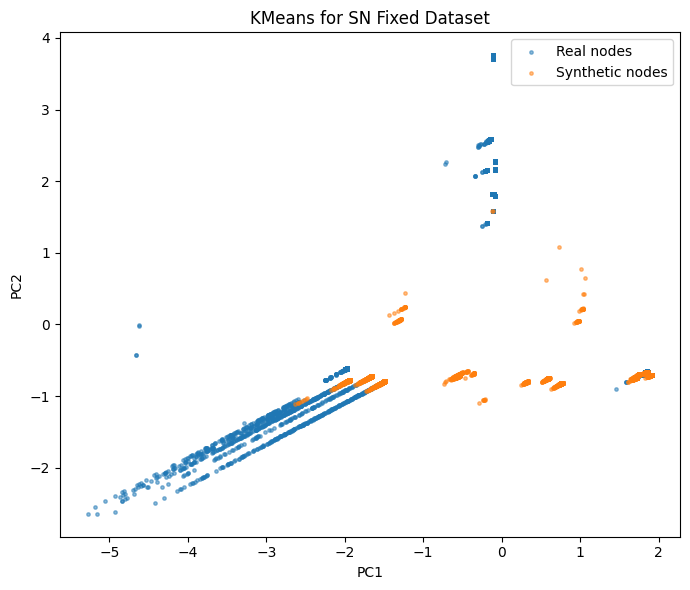

In [82]:
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X_feat)

plt.figure(figsize=(7, 6))
plt.scatter(Xp[origin == 0, 0], Xp[origin == 0, 1], s=6, alpha=0.5, label="Real nodes")
plt.scatter(
    Xp[origin == 1, 0], Xp[origin == 1, 1], s=6, alpha=0.5, label="Synthetic nodes"
)
plt.title("KMeans for SN Fixed Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_fixed_SN_PCA.png", dpi=300, bbox_inches="tight")

## Nearest-neighbor Similarity Plot 

In [24]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

X_real = X_feat[origin == 0]
X_syn = X_feat[origin == 1]

print(f"X_real: {X_real.shape}")
print(f"X_syn: {X_syn.shape}")

# Real -> Real (Exclude self)
nn_real = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_rr, idx_rr = nn_real.kneighbors(X_real)
dist_rr = dist_rr[:,1]

# Synthetic -> Real 
nn_real_1 = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_sr, idx_sr = nn_real_1.kneighbors(X_syn)
dist_sr = dist_sr[:, 0]

nn_syn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=-1    
).fit(X_syn)

dist_rs, idx_rs = nn_syn.kneighbors(X_real)
dist_rs = dist_rs[:, 0]



X_real: (11649, 72)
X_syn: (11649, 72)


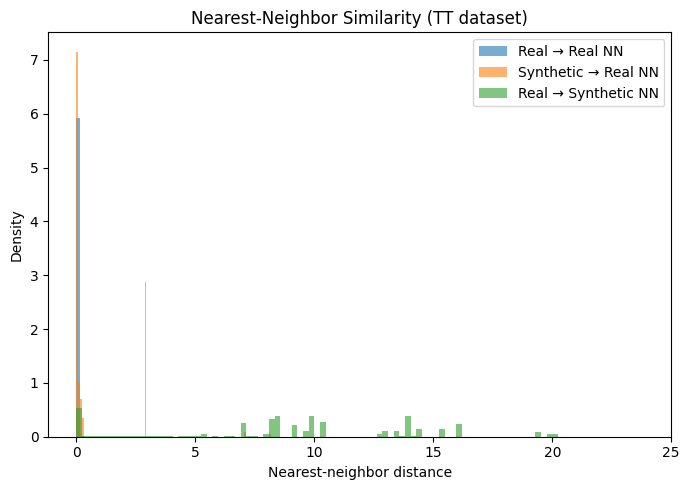

In [25]:
# ----------------------------
# Plot distributions
# ----------------------------
plt.figure(figsize=(7,5))

plt.hist(
    dist_rr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Real NN"
)

plt.hist(
    dist_sr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Synthetic → Real NN"
)

plt.hist(
    dist_rs,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Synthetic NN"
)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Density")
plt.title("Nearest-Neighbor Similarity (TT dataset)")
plt.legend()

plt.tight_layout()
plt.show()


In [26]:
def summarize(name, d):
    print(
        f"{name:25s} "
        f"mean={d.mean():.4f}  "
        f"p10={np.percentile(d,10):.4f}  "
        f"p50={np.percentile(d,50):.4f}  "
        f"p90={np.percentile(d,90):.4f}"
    )

print("\n=== NN Distance Summary ===")
summarize("Real → Real", dist_rr)
summarize("Synthetic → Real", dist_sr)
summarize("Real → Synthetic", dist_rs)


=== NN Distance Summary ===
Real → Real               mean=0.0098  p10=0.0000  p50=0.0000  p90=0.0001
Synthetic → Real          mean=0.8038  p10=0.0040  p50=0.0489  p90=2.9098
Real → Synthetic          mean=9.4437  p10=0.0043  p50=9.5422  p90=15.4707


### Real-vs-Fake RF Model

In [27]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [28]:
X_real[0], X_syn[0]

(array([-0.21539658, -0.15138976, -0.07255388,  1.3570431 , -0.12945391,
        -0.87410784, -0.12996711, -0.07461759, -0.07134841, -0.07461759,
        -0.28909776, -0.12996711, -0.10705754, -0.10582021, -0.11459807,
        -0.11108696, -0.10705754, -0.11498191, -0.15921646, -0.1011597 ,
        -0.08076833, -0.08263174, -0.3139231 ,  4.1998096 , -0.41400638,
        -0.07134841, -0.07461759, -0.07461759, -0.07461759, -0.07255388,
        -0.07461759, -0.07490786, -0.07461759, -0.07461759, -0.07461759,
        -0.07461759, -0.07461759, -0.07134841, -0.07461759, -0.07461759,
        -0.08103709, -0.36726335, -0.21099564, -0.07461759, -0.15330707,
        -0.15374643, -0.08103709, -0.07995679, -0.07374007, -0.0849691 ,
        -0.07548513, -0.09514163, -0.11187626, -0.10072577, -0.1382589 ,
        -0.07995679, -0.1318329 , -0.1314955 , -0.10726244, -0.07461759,
        -0.07461759, -0.07104391, -0.28839988, -0.08103709, -0.15374643,
        -0.07461759, -0.07461759, -0.07461759, -0.0

In [29]:
# X_real, X_syn: numpy arrays (N, D)
X_real = np.asarray(X_real)
X_syn  = np.asarray(X_syn)
X_real.shape, X_syn.shape

((11649, 72), (11649, 72))

In [30]:
# 1) Build X and y
X = np.vstack([X_real, X_syn])
y = np.concatenate([
    np.zeros(len(X_real), dtype=np.int64),
    np.ones(len(X_syn),  dtype=np.int64),
])

# 2) Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3) Simple, conservative RF discriminator
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

# 4) Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"RF real-vs-synthetic accuracy: {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=["Real", "Synthetic"]))



RF real-vs-synthetic accuracy: 0.9890
Confusion matrix (rows=true, cols=pred):
[[3433   62]
 [  15 3480]]

Report:
              precision    recall  f1-score   support

        Real       1.00      0.98      0.99      3495
   Synthetic       0.98      1.00      0.99      3495

    accuracy                           0.99      6990
   macro avg       0.99      0.99      0.99      6990
weighted avg       0.99      0.99      0.99      6990



# SN Variable Dataset

In [88]:
real = LoadDataset(datapath="./processed/SN_data.pt")
synthetic = LoadDataset(datapath="./processed/not_exact_replica/SN_synthetic.pt")

In [89]:
Xr = extract_nodes(real).float()
Xs = extract_nodes(synthetic).float()

print(Xr.shape, Xs.shape)

torch.Size([11649, 3]) torch.Size([20525, 3])


In [90]:
X_feat, origin = preprocess_sid_op_duration(Xr, Xs)

X_feat = StandardScaler().fit_transform(X_feat)

print(
    "Final feature matrix:",
    X_feat.shape,
    "(one-hot sid + one-hot op + scaled duration)",
)

k = 2
km = KMeans(n_clusters=k, n_init=20, random_state=42)
cluster_id = km.fit_predict(X_feat)

print("\n=== Cluster mixing (fraction synthetic per cluster) ===")
for c in range(k):
    idx = np.where(cluster_id == c)[0]
    frac_syn = origin[idx].mean() if len(idx) else float("nan")
    print(f"cluster {c:02d}: n={len(idx):6d}  frac_syn={frac_syn:.3f}")

nmi = normalized_mutual_info_score(origin, cluster_id)
print("\nNMI(origin vs cluster):", float(nmi), " (0=mixed, higher=separable)")


Final feature matrix: (32174, 72) (one-hot sid + one-hot op + scaled duration)

=== Cluster mixing (fraction synthetic per cluster) ===
cluster 00: n= 17193  frac_syn=0.831
cluster 01: n= 14981  frac_syn=0.417

NMI(origin vs cluster): 0.14150059234036813  (0=mixed, higher=separable)


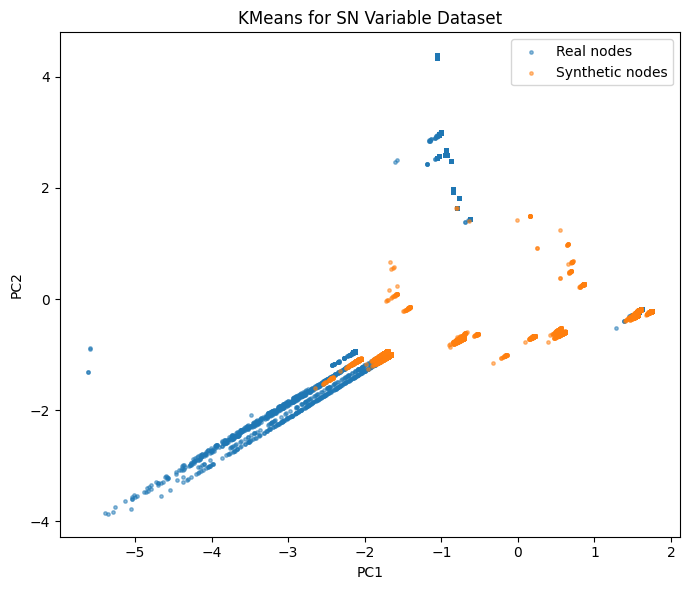

In [91]:
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(X_feat)

plt.figure(figsize=(7, 6))
plt.scatter(Xp[origin == 0, 0], Xp[origin == 0, 1], s=6, alpha=0.5, label="Real nodes")
plt.scatter(
    Xp[origin == 1, 0], Xp[origin == 1, 1], s=6, alpha=0.5, label="Synthetic nodes"
)
plt.title("KMeans for SN Variable Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
# plt.show()
plt.savefig("kmeans_variable_SN_PCA.png", dpi=300, bbox_inches="tight")

## Nearest-neighbor Similarity Plot 

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

X_real = X_feat[origin == 0]
X_syn = X_feat[origin == 1]

print(f"X_real: {X_real.shape}")
print(f"X_syn: {X_syn.shape}")

# Real -> Real (Exclude self)
nn_real = NearestNeighbors(
    n_neighbors=2,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_rr, idx_rr = nn_real.kneighbors(X_real)
dist_rr = dist_rr[:,1]

# Synthetic -> Real 
nn_real_1 = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=1
).fit(X_real)

dist_sr, idx_sr = nn_real_1.kneighbors(X_syn)
dist_sr = dist_sr[:, 0]

nn_syn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    n_jobs=-1    
).fit(X_syn)

dist_rs, idx_rs = nn_syn.kneighbors(X_real)
dist_rs = dist_rs[:, 0]



X_real: (11649, 72)
X_syn: (11649, 72)


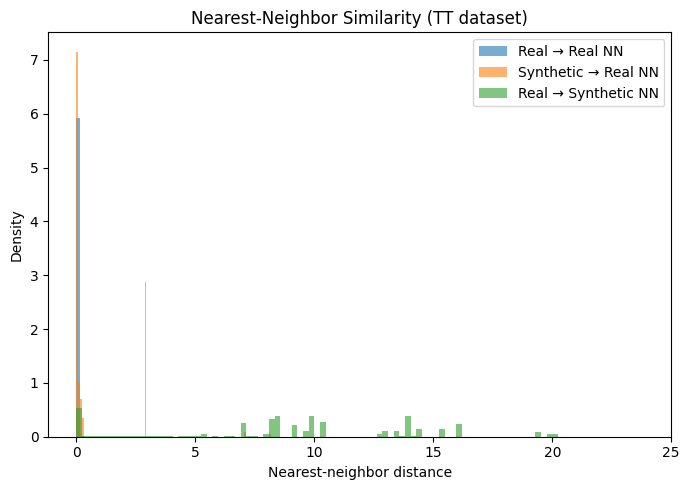

In [ ]:
# ----------------------------
# Plot distributions
# ----------------------------
plt.figure(figsize=(7,5))

plt.hist(
    dist_rr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Real NN"
)

plt.hist(
    dist_sr,
    bins=100,
    density=True,
    alpha=0.6,
    label="Synthetic → Real NN"
)

plt.hist(
    dist_rs,
    bins=100,
    density=True,
    alpha=0.6,
    label="Real → Synthetic NN"
)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Density")
plt.title("Nearest-Neighbor Similarity (TT dataset)")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
def summarize(name, d):
    print(
        f"{name:25s} "
        f"mean={d.mean():.4f}  "
        f"p10={np.percentile(d,10):.4f}  "
        f"p50={np.percentile(d,50):.4f}  "
        f"p90={np.percentile(d,90):.4f}"
    )

print("\n=== NN Distance Summary ===")
summarize("Real → Real", dist_rr)
summarize("Synthetic → Real", dist_sr)
summarize("Real → Synthetic", dist_rs)


=== NN Distance Summary ===
Real → Real               mean=0.0098  p10=0.0000  p50=0.0000  p90=0.0001
Synthetic → Real          mean=0.8038  p10=0.0040  p50=0.0489  p90=2.9098
Real → Synthetic          mean=9.4437  p10=0.0043  p50=9.5422  p90=15.4707


### Real-vs-Fake RF Model

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
X_real[0], X_syn[0]

(array([-0.21539658, -0.15138976, -0.07255388,  1.3570431 , -0.12945391,
        -0.87410784, -0.12996711, -0.07461759, -0.07134841, -0.07461759,
        -0.28909776, -0.12996711, -0.10705754, -0.10582021, -0.11459807,
        -0.11108696, -0.10705754, -0.11498191, -0.15921646, -0.1011597 ,
        -0.08076833, -0.08263174, -0.3139231 ,  4.1998096 , -0.41400638,
        -0.07134841, -0.07461759, -0.07461759, -0.07461759, -0.07255388,
        -0.07461759, -0.07490786, -0.07461759, -0.07461759, -0.07461759,
        -0.07461759, -0.07461759, -0.07134841, -0.07461759, -0.07461759,
        -0.08103709, -0.36726335, -0.21099564, -0.07461759, -0.15330707,
        -0.15374643, -0.08103709, -0.07995679, -0.07374007, -0.0849691 ,
        -0.07548513, -0.09514163, -0.11187626, -0.10072577, -0.1382589 ,
        -0.07995679, -0.1318329 , -0.1314955 , -0.10726244, -0.07461759,
        -0.07461759, -0.07104391, -0.28839988, -0.08103709, -0.15374643,
        -0.07461759, -0.07461759, -0.07461759, -0.0

In [ ]:
# X_real, X_syn: numpy arrays (N, D)
X_real = np.asarray(X_real)
X_syn  = np.asarray(X_syn)
X_real.shape, X_syn.shape

((11649, 72), (11649, 72))

In [ ]:
# 1) Build X and y
X = np.vstack([X_real, X_syn])
y = np.concatenate([
    np.zeros(len(X_real), dtype=np.int64),
    np.ones(len(X_syn),  dtype=np.int64),
])

# 2) Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3) Simple, conservative RF discriminator
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

# 4) Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"RF real-vs-synthetic accuracy: {acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
print("\nReport:")
print(classification_report(y_test, y_pred, target_names=["Real", "Synthetic"]))



RF real-vs-synthetic accuracy: 0.9890
Confusion matrix (rows=true, cols=pred):
[[3433   62]
 [  15 3480]]

Report:
              precision    recall  f1-score   support

        Real       1.00      0.98      0.99      3495
   Synthetic       0.98      1.00      0.99      3495

    accuracy                           0.99      6990
   macro avg       0.99      0.99      0.99      6990
weighted avg       0.99      0.99      0.99      6990

